In [45]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler

!pip install pmdarima
from pmdarima import auto_arima

# importing util
import os
os.chdir('/content/drive/MyDrive/DSSI/Project/code')
import utils

print('finished imports!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
finished imports!


In [2]:
monthly_all_df = pd.read_csv('/content/drive/MyDrive/DSSI/Project/code/monthly_dataset.csv', parse_dates=['Year-Month'])
monthly_all_df['diff_rate_per_100k'] = monthly_all_df['rate_per_100k'].diff()
monthly_all_df['diff_rate_per_100k'].fillna(method='backfill', inplace=True)
monthly_all_df

/tmp/ipykernel_4893/3256535164.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  monthly_all_df['diff_rate_per_100k'].fillna(method='backfill', inplace=True)
/tmp/ipykernel_4893/3256535164.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  monthly_all_df['diff_rate_per_100k'].fillna(method='backfill', inplace=True)


,Year-Month,Precipitation,Avg Rel Hum (%),Avg Wind Speed (mph),Wind Run (miles),windeventcount,Avg Soil Temp (F),AQI_PM25,AQI_PM10,FIRE_Acres_Burned,fungicide_lbs_prd_used,rodent_lbs_prd_used,rate_per_100k,diff_rate_per_100k
0,2001-01-01,3.297857,68.875000,3.522294,2618.515476,0.071429,50.526140,90.4375,40.5000,NaN,4395.45360,633.69475,1.047661,-0.422359
1,2001-02-01,4.035595,72.722462,3.916194,2586.921429,0.166667,52.125481,58.8750,19.6875,NaN,9071.70725,813.86195,0.625301,-0.422359
2,2001-03-01,1.575238,75.960526,3.718078,2731.164286,0.261905,59.033824,64.8125,31.5000,NaN,17723.88265,1338.29970,0.590922,-0.034380
3,2001-04-01,0.996429,69.248725,4.151603,2970.052381,0.047619,61.664271,53.6250,26.6875,NaN,33417.33930,1220.31340,0.389830,-0.201092
4,2001-05-01,0.140476,65.798855,4.007988,2980.953571,0.214286,69.491572,65.1875,39.1250,NaN,22334.85285,1341.28055,0.936698,0.546868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,2024-08-01,0.544191,55.632990,3.595854,2674.035376,0.034091,77.821805,56.0000,39.2500,52890.0,NaN,NaN,9.684514,1.282228
284,2024-09-01,0.263324,58.514057,3.270548,2349.681507,0.056818,75.303352,55.0625,41.2500,76615.5,NaN,NaN,10.127484,0.442970
285,2024-10-01,0.179034,57.233556,3.168064,2328.647200,0.116883,69.680384,59.3750,49.0000,1021.0,NaN,NaN,11.848059,1.720575
286,2024-11-01,0.845889,59.086648,3.398240,2445.109186,0.295996,58.672030,56.1250,34.0000,2574.5,NaN,NaN,11.813999,-0.034061


In [94]:
# SARIMAX model using only rate

In [95]:
# X_train, X_test, y_train, y_test = utils.test_train(TRAIN_FRAC, X_scaled, y)
TRAIN_FRAC=0.80
X_train, X_test, y_train, y_test = utils.test_train(TRAIN_FRAC, X, y)

test_dates = monthly_all_df["Year-Month"].iloc[split:]

In [96]:
# auto ARIMA to find the best parameters
auto_model = auto_arima(y_train, seasonal=True, m=12, trace=True, error_action='ignore', suppress_warnings=True, enforce_stationarity=False, enforce_invertibility=False)
order = auto_model.order
seasonal_order = auto_model.seasonal_order

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.87 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-89.981, Time=0.05 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=-118.904, Time=0.14 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=-109.783, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=-91.787, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=-90.769, Time=0.03 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=-121.821, Time=0.58 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=1.52 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.63 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : AIC=-122.539, Time=0.41 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=-118.773, Time=0.10 sec
 ARIMA(0,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=1.18 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.54 sec
 ARIMA(0,1,1)(2,0,0)[12] intercept   : AIC=-121.547, Time=0.46 sec
 ARIMA(1,1,1)(2,0,0)[12] intercept   : AIC=-120

In [97]:
# sarima model to predict VF rate

sarimax_model = SARIMAX(
    endog=y_train,
    trend='n',
    order=order,
    seasonal_order=seasonal_order
)

results = sarimax_model.fit()
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      rate_per_100k   No. Observations:                  230
Model:             SARIMAX(0, 1, 0)x(2, 0, 0, 12)   Log Likelihood                  65.219
Date:                            Mon, 06 Jul 2026   AIC                           -124.438
Time:                                    20:11:00   BIC                           -114.137
Sample:                                         0   HQIC                          -120.282
                                            - 230                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12       0.3082      0.066      4.691      0.000       0.179       0.437
ar.S.L24       0.1685      0.082   

In [98]:
# training pred (in-sample preds)
train_pred = results.get_prediction(
    start=0,
    end=len(y_train)-1,
    exog=None
)

train_pred_log = train_pred.predicted_mean
train_pred_original = np.expm1(train_pred_log)

y_train_original = np.expm1(y_train)
train_dates = monthly_all_df["Year-Month"].iloc[:split]

# test pred (forecast)
forecast = results.get_forecast(
    steps=len(y_test),
    exog=None)

test_pred_log = forecast.predicted_mean
test_pred_original = np.expm1(test_pred_log)
y_test_original = np.expm1(y_test)

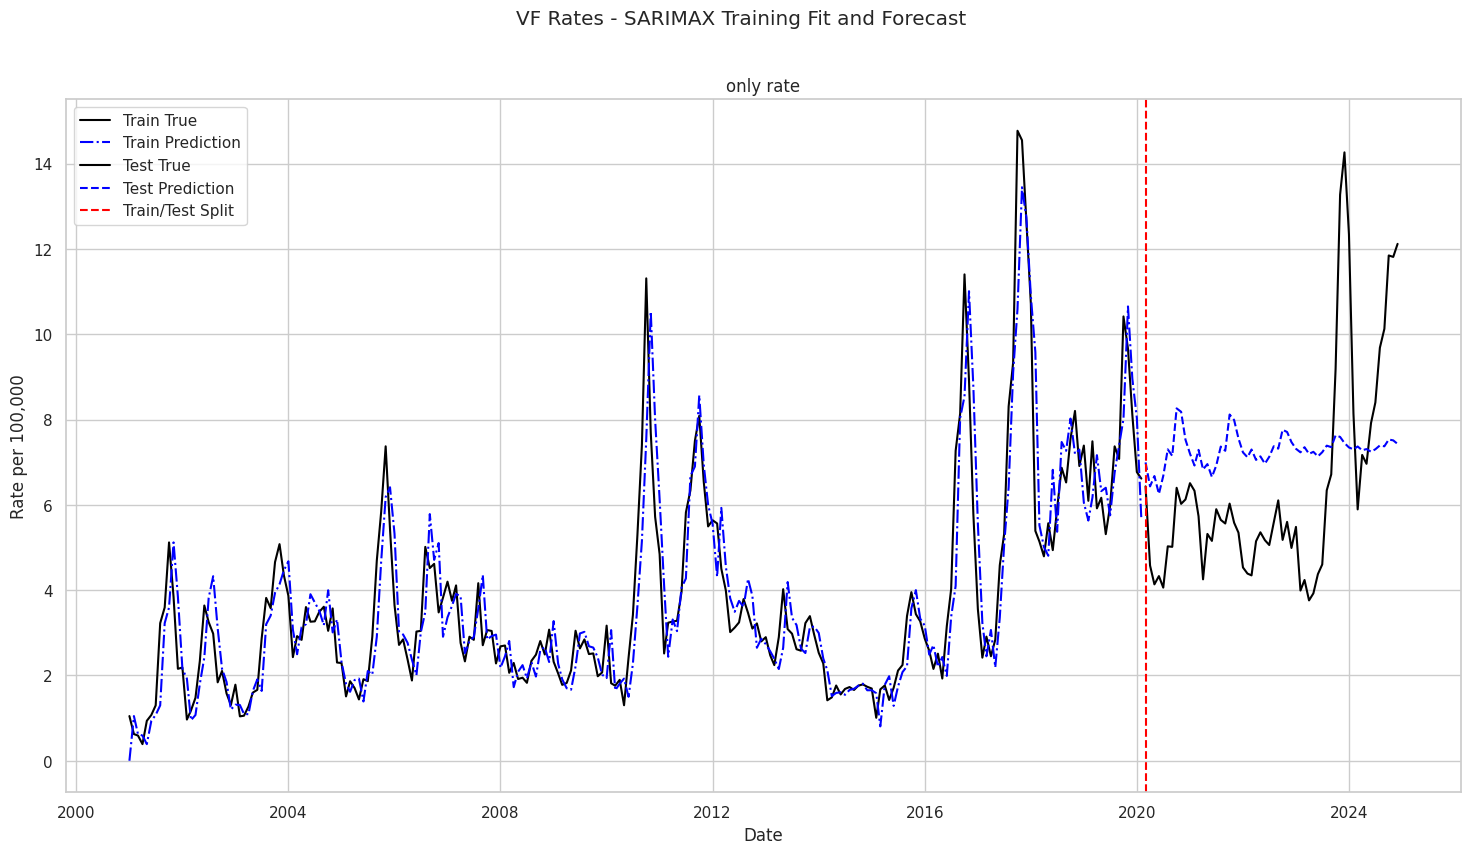

Model                           RMSE=2.56693   MAE=2.22581
{'RMSE': np.float64(2.5669267349036793), 'MAE': 2.225809153737657}


In [99]:
sns.set(style="whitegrid")
plt.figure(figsize=(18, 9))

# train
plt.plot(train_dates, y_train_original, color='black', label='Train True')
plt.plot(train_dates, train_pred_original, color='blue', linestyle='-.', label='Train Prediction')

# test
plt.plot(test_dates, y_test_original, color='black', label='Test True')
plt.plot(test_dates, test_pred_original, color='blue', linestyle='--', label='Test Prediction')

# show train/test split
plt.axvline(test_dates.iloc[0], color='red', linestyle='--', label='Train/Test Split')

plt.suptitle("VF Rates - SARIMAX Training Fit and Forecast")
plt.title("only rate")
plt.xlabel("Date")
plt.ylabel("Rate per 100,000")
plt.legend()

plt.show()

print(utils.compute_metrics(y_test_original, test_pred_original))

In [100]:
# SARIMAX model using all exogenous variables except fire, fungicide, rodent

In [101]:
X = monthly_all_df.drop(columns=['Year-Month','rate_per_100k','diff_rate_per_100k','FIRE_Acres_Burned','fungicide_lbs_prd_used', 'rodent_lbs_prd_used'])
y = np.log1p(monthly_all_df['rate_per_100k']) # using the log1p of the target variable

TRAIN_FRAC = 0.80
split = int(TRAIN_FRAC * len(y))

# Scale the features and target variable
# scaler_X = MinMaxScaler()
# X_scaled = scaler_X.fit_transform(X) #fix

# X_train, X_test, y_train, y_test = utils.test_train(TRAIN_FRAC, X_scaled, y)
X_train, X_test, y_train, y_test = utils.test_train(TRAIN_FRAC, X, y)

test_dates = monthly_all_df["Year-Month"].iloc[split:]

In [102]:
# auto ARIMA to find the best parameters
auto_model = auto_arima(y_train, exogenous=X_train, seasonal=True, m=12, trace=True, error_action='ignore', suppress_warnings=True, enforce_stationarity=False, enforce_invertibility=False)
order = auto_model.order
seasonal_order = auto_model.seasonal_order

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.91 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-89.981, Time=0.05 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=-118.904, Time=0.15 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=-109.783, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=-91.787, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=-90.769, Time=0.04 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=-121.821, Time=0.62 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=1.65 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.62 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : AIC=-122.539, Time=0.44 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=-118.773, Time=0.13 sec
 ARIMA(0,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=1.21 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.51 sec
 ARIMA(0,1,1)(2,0,0)[12] intercept   : AIC=-121.547, Time=0.49 sec
 ARIMA(1,1,1)(2,0,0)[12] intercept   : AIC=-120

In [103]:
print(auto_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  230
Model:             SARIMAX(0, 1, 0)x(2, 0, 0, 12)   Log Likelihood                  65.219
Date:                            Mon, 06 Jul 2026   AIC                           -124.438
Time:                                    20:11:13   BIC                           -114.137
Sample:                                         0   HQIC                          -120.282
                                            - 230                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12       0.3082      0.066      4.691      0.000       0.179       0.437
ar.S.L24       0.1685      0.082   

In [114]:
# sarima model to predict VF rate

sarimax_model = SARIMAX(
    endog=y_train,
    exog=X_train,
    trend='n',
    order=order,
    seasonal_order=seasonal_order
)

results = sarimax_model.fit()
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      rate_per_100k   No. Observations:                  230
Model:             SARIMAX(0, 1, 0)x(2, 0, 0, 12)   Log Likelihood                  76.124
Date:                            Mon, 06 Jul 2026   AIC                           -130.247
Time:                                    20:13:17   BIC                            -92.476
Sample:                                         0   HQIC                          -115.010
                                            - 230                                         
Covariance Type:                              opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Precipitation           -0.0055      0.013     -0.426      0.670      -0.031       0.020
Avg R

In [115]:
# training pred (in-sample preds)
train_pred = results.get_prediction(
    start=0,
    end=len(y_train)-1,
    exog=X_train
)

train_pred_log = train_pred.predicted_mean
train_pred_original = np.expm1(train_pred_log)

y_train_original = np.expm1(y_train)
train_dates = monthly_all_df["Year-Month"].iloc[:split]

# test pred (forecast)
forecast = results.get_forecast(
    steps=len(y_test),
    exog=X_test)

test_pred_log = forecast.predicted_mean
test_pred_original = np.expm1(test_pred_log)
y_test_original = np.expm1(y_test)

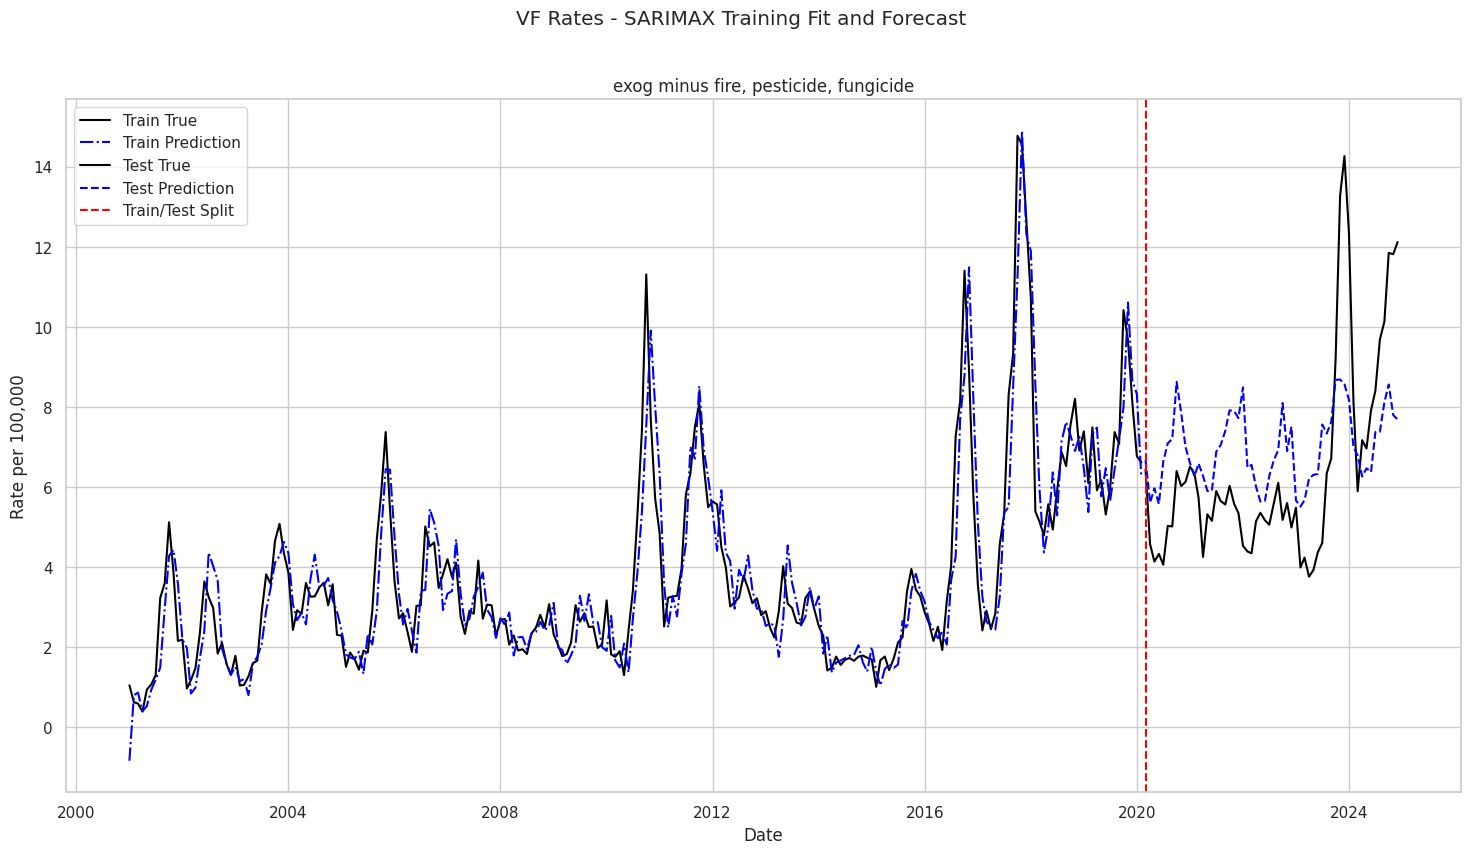

Model                           RMSE=2.14690   MAE=1.77265
{'RMSE': np.float64(2.1469005362224145), 'MAE': 1.7726488766510162}


In [117]:
sns.set(style="whitegrid")
plt.figure(figsize=(18, 9))

# train
plt.plot(train_dates, y_train_original, color='black', label='Train True')
plt.plot(train_dates, train_pred_original, color='blue', linestyle='-.', label='Train Prediction')

# test
plt.plot(test_dates, y_test_original, color='black', label='Test True')
plt.plot(test_dates, test_pred_original, color='blue', linestyle='--', label='Test Prediction')

# show train/test split
plt.axvline(test_dates.iloc[0], color='red', linestyle='--', label='Train/Test Split')

plt.suptitle("VF Rates - SARIMAX Training Fit and Forecast")
plt.title("exog minus fire, pesticide, fungicide")
plt.xlabel("Date")
plt.ylabel("Rate per 100,000")
plt.legend()

plt.show()

print(utils.compute_metrics(y_test_original, test_pred_original))

In [162]:
def sarimax_pipeline(TRAIN_FRAC, X, y, trace, graph):
    """
    Runs the SARIMAX model pipeline given an X (features)
    and y (target variable)

    Parameters
    ----------
    TRAIN_FRAC : float, percent to train on
    X : array of features to use in model
    y : target variable you are trying to predict
    trace : boolean, True if you want to see a trace of the steps,
            False if you want to hide the steps
    graph: boolean, True if you want to print a graph of the model preds vs
           the actual values, False if you want to hide the graph

    Returns
    -------
    A dict with the following:
        "model": results,
        "auto_model": auto_model,
        "order": order,
        "seasonal_order": seasonal_order,
        "train_pred": train_pred_original,
        "test_pred": test_pred_original,
        "y_train": y_train_original,
        "y_test": y_test_original,
        "metrics": utils.compute_metrics(y_test_original, test_pred_original)
    """

    split = int(TRAIN_FRAC * len(y))

    # Scale the features and target variable
    # scaler_X = MinMaxScaler()
    # X_scaled = scaler_X.fit_transform(X) #fix

    # X_train, X_test, y_train, y_test = utils.test_train(TRAIN_FRAC, X_scaled, y)
    X_train, X_test, y_train, y_test = utils.test_train(TRAIN_FRAC, X, y)

    test_dates = monthly_all_df["Year-Month"].iloc[split:]


    # auto ARIMA to find the best parameters
    auto_model = auto_arima(y_train, exogenous=X_train, seasonal=True, m=12, trace=trace, error_action='ignore', suppress_warnings=True, enforce_stationarity=False, enforce_invertibility=False)
    order = auto_model.order
    seasonal_order = auto_model.seasonal_order

    # model
    sarimax_model = SARIMAX(
        endog=y_train,
        exog=X_train,
        trend='n',
        order=order,
        seasonal_order=seasonal_order
    )

    results = sarimax_model.fit()
    print(results.summary()) if (trace) else None


    # training pred (in-sample preds)
    train_pred = results.get_prediction(
        start=0,
        end=len(y_train)-1,
        exog=X_train
    )

    train_pred_log = train_pred.predicted_mean
    train_pred_original = np.expm1(train_pred_log)

    y_train_original = np.expm1(y_train)
    train_dates = monthly_all_df["Year-Month"].iloc[:split]

    # test pred (forecast)
    forecast = results.get_forecast(
        steps=len(y_test),
        exog=X_test)

    test_pred_log = forecast.predicted_mean
    test_pred_original = np.expm1(test_pred_log)
    y_test_original = np.expm1(y_test)

    if (graph):
        sns.set(style="whitegrid")
        plt.figure(figsize=(18, 9))

        # train
        plt.plot(train_dates, y_train_original, color='black', label='Train True')
        plt.plot(train_dates, train_pred_original, color='blue', linestyle='-.', label='Train Prediction')

        # test
        plt.plot(test_dates, y_test_original, color='black', label='Test True')
        plt.plot(test_dates, test_pred_original, color='blue', linestyle='--', label='Test Prediction')

        # show train/test split
        plt.axvline(test_dates.iloc[0], color='red', linestyle='--', label='Train/Test Split')

        plt.suptitle("VF Rates - SARIMAX Training Fit and Forecast")
        plt.xlabel("Date")
        plt.ylabel("Rate per 100,000")
        plt.legend()

        plt.show()

    return {
        "model": results,
        "auto_model": auto_model,
        "order": order,
        "seasonal_order": seasonal_order,
        "train_pred": train_pred_original,
        "test_pred": test_pred_original,
        "y_train": y_train_original,
        "y_test": y_test_original,
        "metrics": utils.compute_metrics(y_test_original, test_pred_original)
    }

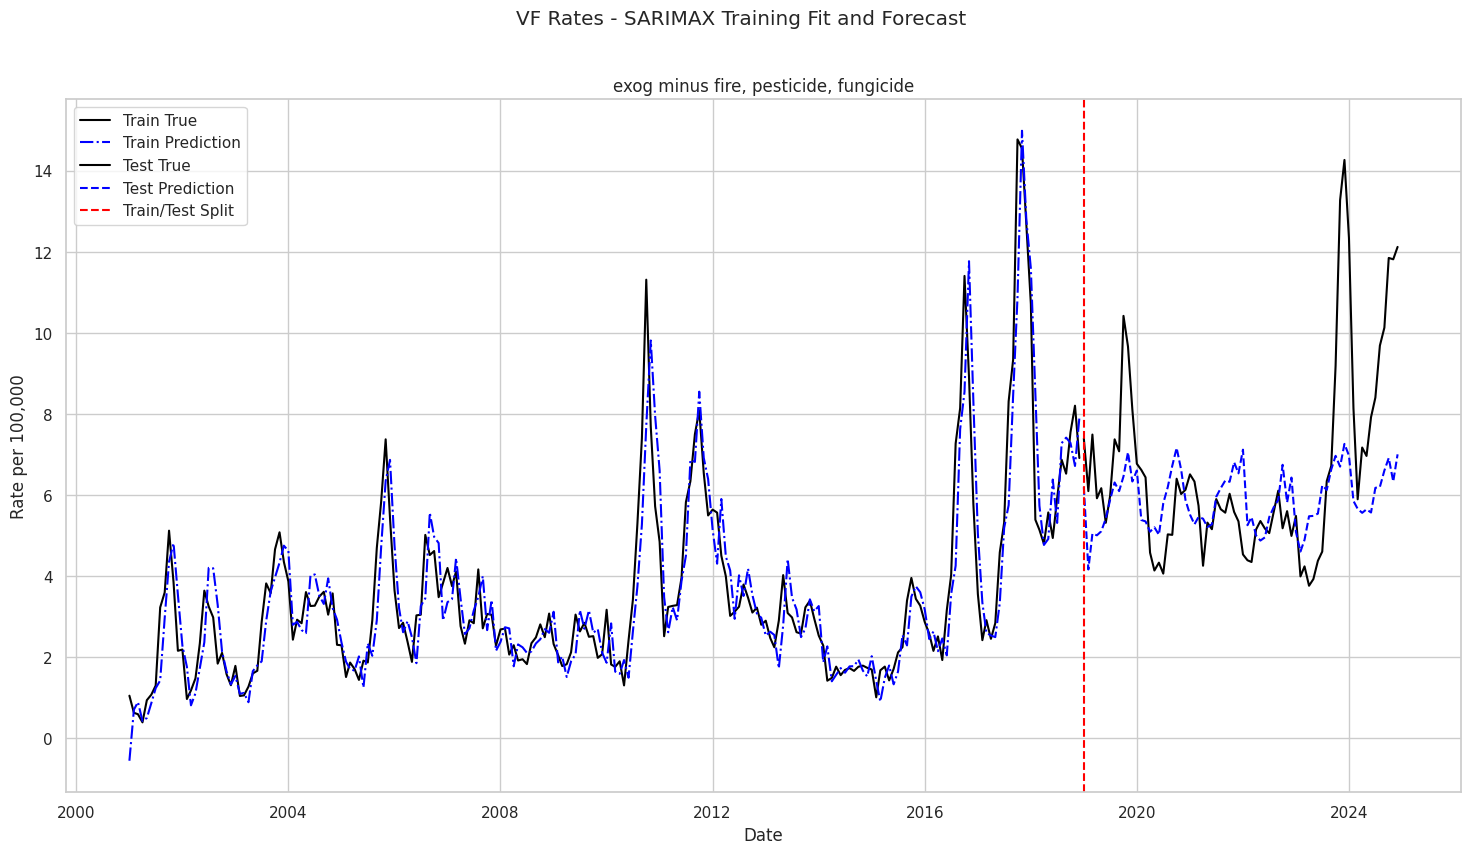

Model                           RMSE=2.16251   MAE=1.50085


In [161]:
X = monthly_all_df[['Precipitation', 'AQI_PM10','Avg Wind Speed (mph)', 'Wind Run (miles)',]]
y = np.log1p(monthly_all_df['rate_per_100k']) # using the log1p of the target variable

four_var_model = sarimax_pipeline(TRAIN_FRAC=0.75, X=X, y=y, trace=False, graph=True)